<a href="https://colab.research.google.com/github/pedrorostagno/tesis/blob/main/Tesis_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

dataset_path = '/content/drive/Othercomputers/My Mac/Data/train'

RUN_DIR = "/content/drive/MyDrive/Tesis UTDT/experimentos/20251003-044034_HIBR"

# "/content/drive/MyDrive/Tesis UTDT/experimentos/20251003-044034_HIBR"
# "/content/drive/MyDrive/Tesis UTDT/experimentos/20251003-021504_CNN_FT"
# "/content/drive/MyDrive/Tesis UTDT/experimentos/20251002-211958_CNN_TL"
# "/content/drive/MyDrive/Tesis UTDT/experimentos/20251003-025327_VIT"


In [4]:
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
import random
import os
import cv2  # 👈 importante para leer imágenes y recortar

class CelebASpoofDatasetFromCSV(Dataset):
    def __init__(self, csv_path, transform=None, max_samples=None,
                 shuffle=True, seed=42, balanced=False, use_bb=False):
        """
        Dataset desde CSV con opción de balanceo y recorte por bounding box.

        CSV esperado con columnas: 'path', 'label'
        - label: 0 (spoof), 1 (live)

        Parámetros extra:
        - use_bb: si True, recorta la cara usando los bounding boxes (_BB.txt)
        """
        self.transform = transform
        self.use_bb = use_bb
        df = pd.read_csv(csv_path)
        random.seed(seed)

        if balanced:
            spoof_df = df[df['label'] == 0]
            live_df  = df[df['label'] == 1]
            min_len = min(len(spoof_df), len(live_df))

            spoof_df = spoof_df.sample(n=min_len, random_state=seed)
            live_df  = live_df.sample(n=min_len, random_state=seed)
            df = pd.concat([spoof_df, live_df], ignore_index=True)

            print(f"⚖️ Dataset balanceado: {min_len} spoof + {min_len} live = {2 * min_len} total")

        if shuffle:
            df = df.sample(frac=1, random_state=seed).reset_index(drop=True)

        if max_samples:
            df = df.head(max_samples)

        self.image_paths = df['path'].tolist()
        self.labels = df['label'].tolist()

        print(f"📄 CSV cargado: {csv_path}")
        print(f"📊 Total imágenes cargadas: {len(self.image_paths)}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        filename = self.image_paths[idx]
        label = self.labels[idx]

        if self.use_bb:
            # Leer imagen con OpenCV
            img = cv2.imread(filename)
            real_h, real_w, c = img.shape

            # Archivo con bounding box
            bb_file = filename[:-4] + "_BB.txt"
            assert os.path.exists(bb_file), f"Bounding box file not found: {bb_file}"

            with open(bb_file, "r") as f:
                x, y, w, h, score = f.readline().strip().split(" ")

            # Convertir a int + escalar a resolución original
            x, y, w, h = map(float, (x, y, w, h))
            x = int(x * real_w / 224)
            y = int(y * real_h / 224)
            w = int(w * real_w / 224)
            h = int(h * real_h / 224)

            # Asegurar límites válidos
            x1, y1 = max(0, x), max(0, y)
            x2, y2 = min(real_w, x1 + w), min(real_h, y1 + h)

            img = img[y1:y2, x1:x2, :]
            assert img.shape[0] > 0 and img.shape[1] > 0, f"Invalid crop: {filename}"

            # Convertir a PIL
            img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

        else:
            # Cargar imagen normal con PIL
            img = Image.open(filename).convert("RGB")

        # Aplicar transformaciones (ImageNet en tu caso)
        if self.transform:
            img = self.transform(img)

        return img, label, filename


In [5]:
from torchvision import models, transforms


# 📐 Dimensiones estándar a las que se redimensionarán todas las imágenes
img_width, img_height = 224, 224

# ⚙️ Tamaño del batch para los DataLoaders
batch_size = 64

# 🌀 Transformaciones de preprocesamiento para cada conjunto de datos
data_transforms = {
    'test': transforms.Compose([
        transforms.Resize((img_width, img_height)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}


In [6]:
import torch

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


In [7]:
import os, json, time
import numpy as np
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torchvision import models
from tqdm import tqdm
from torch import amp


# Para testear la CNN  ─────────────────────────────────────────────
# 1) Creamos la arquitectura con la misma config de entrenamiento
# best_model = models.mobilenet_v2(weights=None)           # no necesitamos pesos ImageNet
# num_ftrs   = best_model.classifier[1].in_features
# best_model.classifier[1] = nn.Linear(num_ftrs, 2)

# # 2) Cargamos SOLO la parte de pesos
# ckpt_path = os.path.join(RUN_DIR, 'best_model.pth')
# ckpt = torch.load(ckpt_path, map_location=device)
# best_model.load_state_dict(ckpt["model_state"])          # <- clave correcta

# best_model.to(device).eval()
# print("✅ Pesos cargados desde checkpoint")


# Para testear ViT ─────────────────────────────────────────────
# from torchvision.models import vit_b_16, ViT_B_16_Weights
# import torch.nn as nn
# import os, torch

# # 1-A  Instanciá la arquitectura *sin* pesos ImageNet (ya los tenés en el checkpoint)
# best_model = vit_b_16(weights=None)              # ← mismo patch-size (16) y 224×224

# # 1-B  Reemplazá la cabeza por la misma que usaste al entrenar
# num_ftrs = best_model.heads.head.in_features     # 768 en ViT-B/16
# best_model.heads.head = nn.Linear(num_ftrs, 2)

# # 2-C  Cargá los pesos entrenados
# ckpt_path = os.path.join(RUN_DIR, "best_model.pth")
# ckpt = torch.load(ckpt_path, map_location=device)
# best_model.load_state_dict(ckpt["model_state"])  # clave igual que antes

# best_model.to(device).eval()
# print("✅ Pesos ViT cargados desde checkpoint")

# ─── MODELO HÍBRIDO · CARGA PARA TEST ───────────────────────────────
import timm, torch.nn as nn
import torch, os

# 1) Instanciá la misma arquitectura que usaste al entrenar
#    · No hace falta volver a bajar pesos de ImageNet: pon pretrained=False
best_model = timm.create_model(
    'coatnet_0_rw_224',            # arquitectura híbrida CNN+SA
    pretrained=False               # solo queremos la estructura
)
best_model.reset_classifier(num_classes=2)  # cabeza binaria

# 2) Cargá los pesos que guardaste en RUN_DIR/best_model.pth
ckpt_path = os.path.join(RUN_DIR, 'best_model.pth')
ckpt = torch.load(ckpt_path, map_location=device)          # device = cuda / cpu
best_model.load_state_dict(ckpt["model_state"])            # ← misma clave que antes

# 3) Pasa a evaluación y al dispositivo
best_model.to(device).eval()
print("✅ Pesos CoAtNet cargados desde checkpoint")



def pad_metrics_from_cm(cm):
    """
    Etiquetas: 0 = spoof (ataque), 1 = live (bona fide)
    cm = [[TN, FP],
          [FN, TP]]
    APCER = cm[0,1] / (cm[0,0] + cm[0,1])
    BPCER = cm[1,0] / (cm[1,0] + cm[1,1])
    ACER  = (APCER + BPCER) / 2
    """
    attack_total = cm[0,0] + cm[0,1]
    bona_total   = cm[1,0] + cm[1,1]
    apcer = cm[0,1] / attack_total if attack_total > 0 else 0.0
    bpcer = cm[1,0] / bona_total   if bona_total > 0 else 0.0
    acer  = 0.5 * (apcer + bpcer)
    return apcer, bpcer, acer

def _metrics_from_preds(y_true, y_pred):
    cm = metrics.confusion_matrix(y_true, y_pred, labels=[0,1])
    apcer, bpcer, acer = pad_metrics_from_cm(cm)
    bal_acc = metrics.balanced_accuracy_score(y_true, y_pred)
    report  = metrics.classification_report(
        y_true, y_pred,
        target_names=["spoof", "live"],
        output_dict=True, zero_division=0
    )
    acc = (y_pred == y_true).mean()
    return {
        "accuracy": float(acc),
        "balanced_accuracy": float(bal_acc),
        "apcer": float(apcer),
        "bpcer": float(bpcer),
        "acer": float(acer),
        "classification_report": report,
        "confusion_matrix": cm.tolist(),
    }


@torch.inference_mode()
def test_model(model, test_loader, criterion, device, output_dir,
               threshold: float | None = None,
               target_apcer: float | None = 0.10,
               filename_suffix: str = ""):
    """
    threshold:
      - None → usa baseline 'argmax'
      - float en [0,1] → decide live si prob_live >= threshold
    target_apcer:
      - Si no es None, calcula un punto de operación que cumpla APCER <= target_apcer
    """
    os.makedirs(output_dir, exist_ok=True)
    model.eval()
    all_labels, all_probs = [], []
    all_preds_argmax = []
    test_loss = 0.0
    total_samples = 0
    all_paths = []


    use_cuda_amp = (device.type == 'cuda')

    start_time = time.time()
    num_batches = len(test_loader)

    for batch_idx, batch in tqdm(enumerate(test_loader),
                                 total=num_batches,
                                 desc="Testing", leave=True):

        if len(batch) == 3:
            inputs, labels, paths = batch
        else:
            inputs, labels = batch
            paths = [None] * inputs.size(0)

        all_paths.extend(paths)

        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with amp.autocast(device_type='cuda', enabled=use_cuda_amp):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        probs_live = torch.softmax(outputs, dim=1)[:, 1]  # prob de clase "live"
        preds_argmax = outputs.argmax(dim=1)

        bs = inputs.size(0)
        test_loss += loss.item() * bs
        total_samples += bs

        all_probs.extend(probs_live.detach().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_preds_argmax.extend(preds_argmax.cpu().numpy())

    total_time = time.time() - start_time
    avg_loss = test_loss / max(1, total_samples)
    print(f"\n✅ Test terminado en {total_time:.1f}s - Loss promedio: {avg_loss:.4f}")

    # Numpy
    y_true  = np.asarray(all_labels, dtype=int)
    p_live  = np.asarray(all_probs, dtype=float)
    y_argmx = np.asarray(all_preds_argmax, dtype=int)

    # AUC siempre por probas
    roc_auc = float(metrics.roc_auc_score(y_true, p_live))

    # Puntos de operación
    ops = {}

    # 1) Baseline: argmax
    ops["argmax"] = _metrics_from_preds(y_true, y_argmx)
    ops["argmax"]["threshold"] = None

    # 2) Youden (TPR-FPR máximo)
    fpr, tpr, thr = metrics.roc_curve(y_true, p_live, pos_label=1)
    youden_idx = int(np.argmax(tpr - fpr))
    thr_youden = float(thr[youden_idx])
    y_youden = (p_live >= thr_youden).astype(int)
    ops["youden"] = _metrics_from_preds(y_true, y_youden)
    ops["youden"]["threshold"] = thr_youden

    # 3) Min ACER en malla fina
    grid = np.linspace(0.0, 1.0, 1001)
    best = {"acer": 1.0, "thr": 0.5, "cm": None}
    for t in grid:
        y_hat = (p_live >= t).astype(int)
        cm = metrics.confusion_matrix(y_true, y_hat, labels=[0,1])
        apcer, bpcer, acer = pad_metrics_from_cm(cm)
        if acer < best["acer"]:
            best.update({"acer": acer, "thr": float(t), "cm": cm})
    y_acer = (p_live >= best["thr"]).astype(int)
    ops["acer_min"] = _metrics_from_preds(y_true, y_acer)
    ops["acer_min"]["threshold"] = best["thr"]

    # 4) APCER objetivo (si se pide)
    if target_apcer is not None:
        thr_target = None
        tuple_target = None
        for t in grid:
            y_hat = (p_live >= t).astype(int)
            cm = metrics.confusion_matrix(y_true, y_hat, labels=[0,1])
            apcer, bpcer, acer = pad_metrics_from_cm(cm)
            if apcer <= target_apcer:
                thr_target = float(t)
                tuple_target = (apcer, bpcer, acer, y_hat)
                break
        if thr_target is not None:
            y_t = tuple_target[3]
            ops[f"apcer<={target_apcer:.2f}"] = _metrics_from_preds(y_true, y_t)
            ops[f"apcer<={target_apcer:.2f}"]["threshold"] = thr_target
        else:
            ops[f"apcer<={target_apcer:.2f}"] = {
                "threshold": None,
                "note": f"No se alcanzó APCER <= {target_apcer:.2f} con thresholds uniformes"
            }

    # Selección para retorno (si threshold explícito, úsalo)
    if threshold is not None:
        thr_used = float(threshold)
        y_sel = (p_live >= thr_used).astype(int)
        cm_sel = metrics.confusion_matrix(y_true, y_sel, labels=[0,1])
        apcer, bpcer, acer = pad_metrics_from_cm(cm_sel)
        sel_metrics = _metrics_from_preds(y_true, y_sel)
        sel_metrics["threshold"] = thr_used
        sel_key = "custom_threshold"
        ops[sel_key] = sel_metrics
        cm_to_return = cm_sel
        report_for_return = sel_metrics["classification_report"]
    else:
        # por compat: devolvemos el baseline argmax
        cm_to_return = np.array(ops["argmax"]["confusion_matrix"])
        report_for_return = ops["argmax"]["classification_report"]

    # Guardado principal
    out_json = {
        "avg_loss": avg_loss,
        "roc_auc": roc_auc,
        "total_time_sec": total_time,
        "num_samples": int(total_samples),
        "num_batches": int(num_batches),
        "operating_points": ops
    }
    with open(os.path.join(output_dir, f'metrics_test{filename_suffix}.json'), 'w') as f:
        json.dump(out_json, f, indent=2)
    print(f"📄 Métricas guardadas en metrics_test{filename_suffix}.json")


    # Guardar predicciones crudas
    import pandas as pd
    df_preds = pd.DataFrame({
        "path": all_paths,
        "label": y_true,
        "pred_argmax": y_argmx,
        "prob_live": p_live
    })
    df_preds.to_csv(os.path.join(output_dir, f"predictions_test{filename_suffix}.csv"), index=False)
    print(f"💾 Predicciones guardadas en predictions_test{filename_suffix}.csv")


    # Matriz de confusión del punto elegido (para la figura)
    plt.figure(figsize=(6,5))
    sns.heatmap(np.array(cm_to_return), annot=True, fmt='d', cmap='Blues',
                xticklabels=["spoof", "live"], yticklabels=["spoof", "live"])
    plt.xlabel("Predicción"); plt.ylabel("Real"); plt.title("Matriz de Confusión")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'confusion_matrix{filename_suffix}.png'))
    plt.close()
    print("🖼️ Matriz de confusión guardada como imagen.")

    # Curva ROC (independiente del threshold)
    fpr, tpr, _ = metrics.roc_curve(y_true, p_live, pos_label=1)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("Curva ROC (live=positivo)")
    plt.legend(loc="lower right"); plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'roc_curve{filename_suffix}.png'))
    plt.close()
    print("📈 Curva ROC guardada como imagen.")

    # Devolvemos: loss promedio, diccionario completo, y CM del punto elegido
    return avg_loss, out_json, np.array(cm_to_return)


✅ Pesos CoAtNet cargados desde checkpoint


In [8]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()  # reduction='mean' por defecto
print("Usando Cross Entropy estándar (sin pesos)")

Usando Cross Entropy estándar (sin pesos)


In [10]:
from torch.utils.data import Dataset, DataLoader

# csv_path='/content/drive/Othercomputers/My Mac/Data/train/test2_balanced_10k.csv',
# csv_path='/content/drive/Othercomputers/My Mac/Data/train/test_image_list.csv',

# 📦 Dataset de test desde CSV
test_dataset = CelebASpoofDatasetFromCSV(
    csv_path='/content/drive/Othercomputers/My Mac/Data/train/test2_balanced_10k.csv',
    transform=data_transforms['test'],
    max_samples=10000,
    balanced=False,
    use_bb=True
)

# 🔄 DataLoaders
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True,
    drop_last=True
)



📄 CSV cargado: /content/drive/Othercomputers/My Mac/Data/train/test2_balanced_10k.csv
📊 Total imágenes cargadas: 10000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
test_loss, test_report, test_cm = test_model(model=best_model, test_loader=test_loader,
                                             criterion=criterion, device=device, output_dir=RUN_DIR,
                                             filename_suffix="_10k_borrar",
                                             threshold=0.937)

# CNN TL  0.878
# CNN FT  0.997
# ViT     0.696
# Híbrido 0.937




/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Testing:   0%|          | 0/156 [00:00<?, ?it/s]

In [1]:
# Graficos

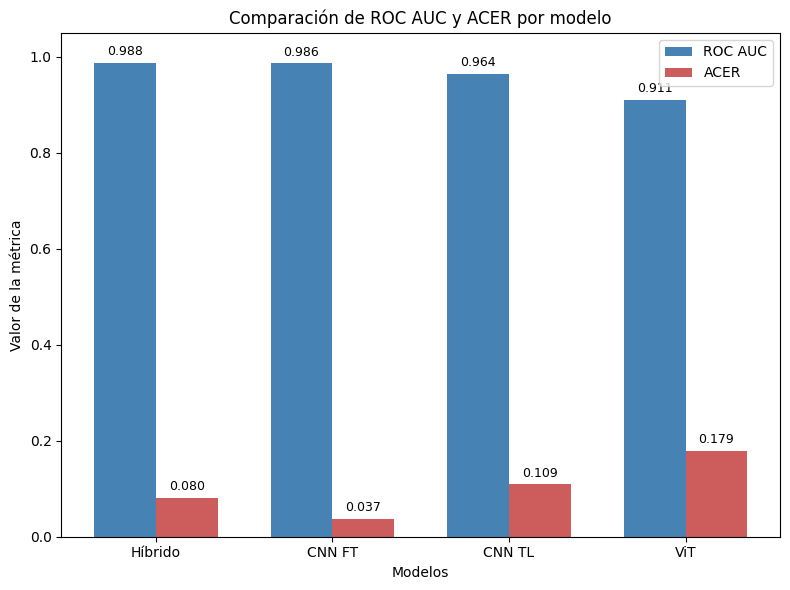

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Datos de las métricas
modelos = ['Híbrido', 'CNN FT', 'CNN TL', 'ViT']
auc = [0.9881, 0.9861, 0.9636, 0.9108]
acer = [0.0801, 0.0374, 0.1089, 0.1788]

# Posiciones para las barras
x = np.arange(len(modelos))
width = 0.35  # ancho de cada barra

# Crear la figura y los ejes
plt.figure(figsize=(8, 6))
bars_auc = plt.bar(x - width/2, auc, width, label='ROC AUC', color='steelblue')
bars_acer = plt.bar(x + width/2, acer, width, label='ACER', color='indianred')

# Etiquetas y título
plt.xlabel('Modelos')
plt.ylabel('Valor de la métrica')
plt.title('Comparación de ROC AUC y ACER por modelo')
plt.xticks(x, modelos)
plt.ylim(0, 1.05)  # ajustar para que entren los textos
plt.legend()

# Anotar valores encima de cada barra
for bars in [bars_auc, bars_acer]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


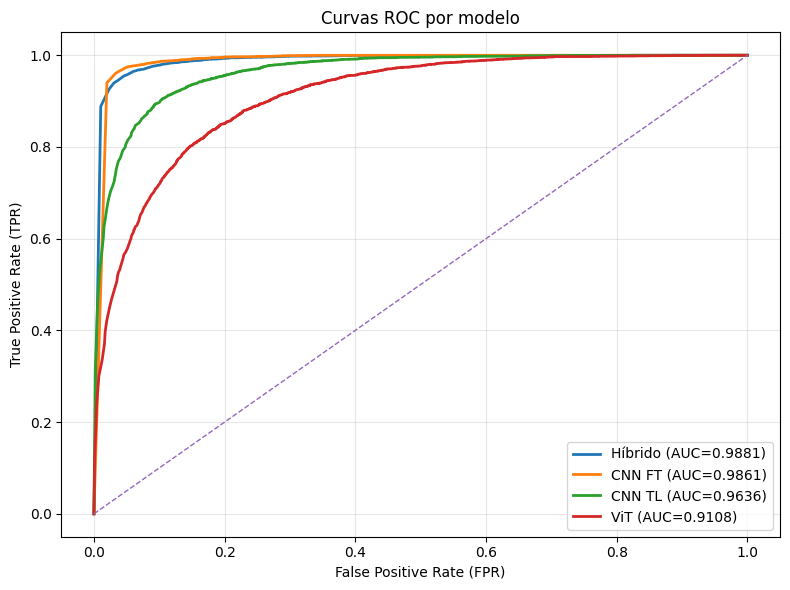

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

paths = {
    "Híbrido": "/content/drive/MyDrive/Tesis UTDT/experimentos/20251003-044034_HIBR/predictions_test_10k_2.csv",
    "CNN FT": "/content/drive/MyDrive/Tesis UTDT/experimentos/20251003-021504_CNN_FT/predictions_test_10k_2.csv",
    "CNN TL": "/content/drive/MyDrive/Tesis UTDT/experimentos/20251002-211958_CNN_TL/predictions_test_10k_2.csv",
    "ViT": "/content/drive/MyDrive/Tesis UTDT/experimentos/20251003-025327_VIT/predictions_test_10k_2.csv",
}


plt.figure(figsize=(8,6))

for name, path in paths.items():
    df = pd.read_csv(path)
    y_true = df["label"].values
    y_score = df["prob_live"].values

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.4f})", linewidth=2)

plt.plot([0,1], [0,1], linestyle='--', linewidth=1)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Curvas ROC por modelo")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


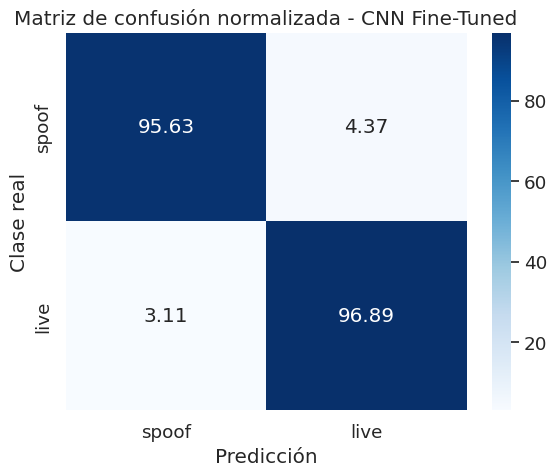

In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Matriz de confusión del modelo CNN FT (valores absolutos)
cm = np.array([
    [4776, 218],
    [155, 4835]
])

# Nombres de las clases (según tu encoding 0 = spoof, 1 = live)
class_names = ['spoof', 'live']

# Normalizamos por fila (para obtener % de predicciones por clase real)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Configurar el gráfico
plt.figure(figsize=(6, 5))
sns.set(font_scale=1.2)
ax = sns.heatmap(
    cm_normalized * 100,  # en %
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

# Títulos y etiquetas
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("Matriz de confusión normalizada - CNN Fine-Tuned")
plt.tight_layout()

# Mostrar
plt.show()


In [6]:
import torch
import time
import os

# Asegurate de tener el modelo cargado
model = best_model.eval()  # eval mode
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 1. Número total de parámetros
num_params = sum(p.numel() for p in model.parameters())
print(f"Número total de parámetros: {num_params:,}")

# 2. Tamaño del archivo .pt
model_path = "/content/drive/MyDrive/Tesis UTDT/experimentos/20251003-044034_HIBR/best_model.pth"  # Cambiá al path real
model_size_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f"Tamaño del archivo: {model_size_mb:.2f} MB")

# 3. Latencia promedio de inferencia
# Suponiendo input size típico (ej: MobileNet: 3x224x224)
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Calentamiento
for _ in range(10):
    _ = model(dummy_input)

# Medición real
num_runs = 100
torch.cuda.synchronize() if device.type == 'cuda' else None
start = time.time()
for _ in range(num_runs):
    _ = model(dummy_input)
torch.cuda.synchronize() if device.type == 'cuda' else None
end = time.time()

latency_ms = (end - start) / num_runs * 1000
print(f"Latencia promedio de inferencia: {latency_ms:.2f} ms")

# 4. Nombre del dispositivo
print(f"Dispositivo evaluado: {device}")


Número total de parámetros: 26,668,100
Tamaño del archivo: 305.49 MB
Latencia promedio de inferencia: 328.57 ms
Dispositivo evaluado: cpu


In [ ]:

# CNN FT con CPU
# Número total de parámetros: 2,226,434
# Tamaño del archivo: 25.84 MB
# Latencia promedio de inferencia: 36.78 ms
# Dispositivo evaluado: cpu


# CNN FT con GPU A100
# Número total de parámetros: 2,226,434
# Tamaño del archivo: 25.84 MB
# Latencia promedio de inferencia: 7.54 ms
# Dispositivo evaluado: cuda


# ---


# Hibrido con CPU
# Número total de parámetros: 26,668,100
# Tamaño del archivo: 305.49 MB
# Latencia promedio de inferencia: 328.57 ms
# Dispositivo evaluado: cpu

# Hibrido con GPU A100
# Número total de parámetros: 26,668,100
# Tamaño del archivo: 305.49 MB
# Latencia promedio de inferencia: 12.60 ms
# Dispositivo evaluado: cuda

In [9]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      2
  On-line CPU(s) list:       0,1
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.20GHz
    CPU family:              6
    Model:                   79
    Thread(s) per core:      2
    Core(s) per socket:      1
    Socket(s):               1
    Stepping:                0
    BogoMIPS:                4399.99
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                   